In [1]:
import os
import json
import torch
from sklearn.metrics import accuracy_score

from gap.image_loader import PetDataProcessor
from gap.classifiers import CustomCNN, train_cnn, evaluate_cnn
from gap.classifiers import train_logistic_regression_cv, evaluate_classical_model
from gap.utils import set_reproducibility_seeds, save_experiment, get_default_device
from gap.evaluator import ModelEvaluator

# lock seed
SEED = 42
set_reproducibility_seeds(SEED)

# Setup Device
device = get_default_device()
print(f"Running on {device}")

# --- Update this path to your downloaded images folder ---
DATA_DIR = "../oxford-iiit-pet/images"

All random seeds locked to 42.
Running on cpu


In [2]:
print("--- Initializing Data Processor ---")
processor = PetDataProcessor(data_dir=DATA_DIR, random_state=SEED)
classes = processor.encoder.classes_
num_classes = len(classes)
print(f"Loaded {num_classes} pet breeds.\n")

print("--- Preparing Data for PyTorch CNN ---")
# Creates batches of image tensors
IMAGE_SIZE = 224
BATCH_SIZE = 32
train_loader, test_loader = processor.get_cnn_dataloaders(
    batch_size=BATCH_SIZE, img_size=IMAGE_SIZE
)

print("\n--- Preparing Data for Scikit-Learn LRCV ---")
# Creates 1D flattened arrays (downscaled to 64x64 to prevent RAM crashes, but should try larger)
X_train, X_test, y_train, y_test = processor.get_flattened_data(img_size=64)

--- Initializing Data Processor ---
Loaded 37 pet breeds.

--- Preparing Data for PyTorch CNN ---

--- Preparing Data for Scikit-Learn LRCV ---
Flattening images for classical ML (this may take a minute)...


In [3]:
print("==================================================")
print(" EXPERIMENT 1: Logistic Regression (Cross-Validated)")
print("==================================================")

# train
max_iter = 200
cv_folds = 3
lrcv_model = train_logistic_regression_cv(
    X_train, y_train, cv_folds=cv_folds, max_iter=max_iter
)

# evaluate
print("\nEvaluating LRCV Test Performance...")
lrcv_y_true, lrcv_y_pred = evaluate_classical_model(
    lrcv_model, X_test, y_test, target_names=classes
)

# save
lrcv_config = {
    "model_type": "LogisticRegressionCV",
    "cv_folds": cv_folds,
    "max_iter": max_iter,
    "image_size_flattened": 64,
    "random_seed": SEED,
    "test_accuracy": accuracy_score(lrcv_y_true, lrcv_y_pred),
    "classes": list(classes),
}
save_experiment(lrcv_model, model_name="LRCV_baseline", config=lrcv_config)

 EXPERIMENT 1: Logistic Regression (Cross-Validated)
Training LogisticRegressionCV with 3 folds...


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/

Best C parameters found (sample): 0.005994842503189409

Evaluating LRCV Test Performance...
Classical Model Test Accuracy: 0.1353

Classification Report:
                            precision    recall  f1-score   support

                Abyssinian       0.13      0.15      0.14        40
                    Bengal       0.09      0.07      0.08        40
                    Birman       0.05      0.03      0.03        40
                    Bombay       0.31      0.55      0.40        40
         British_Shorthair       0.13      0.05      0.07        40
              Egyptian_Mau       0.18      0.25      0.21        40
                Maine_Coon       0.08      0.07      0.08        40
                   Persian       0.09      0.07      0.08        40
                   Ragdoll       0.15      0.25      0.19        40
              Russian_Blue       0.12      0.15      0.14        40
                   Siamese       0.12      0.07      0.09        40
                    Sphynx   

/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


'../saved_models/LRCV_baseline_20260307_1652'

In [3]:
print("==================================================")
print(" EXPERIMENT 2: Custom PyTorch CNN")
print("==================================================")

# initialize
# cnn_model = CustomCNN(num_classes=num_classes, input_size=IMAGE_SIZE)
cnn_model = CustomCNN(num_classes=num_classes)
EPOCHS = 50
LEARNING_RATE = 0.001

# train
print(f"Training CNN for {EPOCHS} epochs...")
trained_cnn, history = train_cnn(
    cnn_model, train_loader, test_loader, EPOCHS, LEARNING_RATE, device
)

# evaluate
print("\nEvaluating CNN Test Performance...")
cnn_y_true, cnn_y_pred = evaluate_cnn(trained_cnn, test_loader, device=device)

# save
cnn_config = {
    "model_type": "CustomCNN",
    "framework": "PyTorch",
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "random_seed": SEED,
    "test_accuracy": accuracy_score(cnn_y_true, cnn_y_pred),
    "classes": list(classes),
}
save_experiment(trained_cnn, model_name="CustomCNN_10Epochs", config=cnn_config)

 EXPERIMENT 2: Custom PyTorch CNN
Training CNN for 50 epochs...
Starting Training for 50 Epochs...

Epoch [01/50] | Train Loss: 3.4215 Acc: 0.0962 | Val Loss: 3.4534 Acc: 0.1076
   Validation accuracy improved to 0.1076!
Epoch [02/50] | Train Loss: 3.0693 Acc: 0.1548 | Val Loss: 2.9507 Acc: 0.1820
   Validation accuracy improved to 0.1820!
Epoch [03/50] | Train Loss: 2.7910 Acc: 0.2241 | Val Loss: 2.7665 Acc: 0.2280
   Validation accuracy improved to 0.2280!
Epoch [04/50] | Train Loss: 2.5050 Acc: 0.2781 | Val Loss: 2.4767 Acc: 0.2963
   Validation accuracy improved to 0.2963!
Epoch [05/50] | Train Loss: 2.2948 Acc: 0.3325 | Val Loss: 3.4657 Acc: 0.1698
Epoch [06/50] | Train Loss: 2.0881 Acc: 0.3887 | Val Loss: 2.6822 Acc: 0.2828
Epoch [07/50] | Train Loss: 1.9011 Acc: 0.4318 | Val Loss: 2.1153 Acc: 0.3843
   Validation accuracy improved to 0.3843!
Epoch [08/50] | Train Loss: 1.6806 Acc: 0.4877 | Val Loss: 1.9818 Acc: 0.4290
   Validation accuracy improved to 0.4290!
Epoch [09/50] | Tr

'../saved_models/CustomCNN_10Epochs_20260307_2005'

In [5]:
MODEL_PATH = "../saved_models/CustomCNN_10Epochs_20260307_2005"

with open(os.path.join(MODEL_PATH, "metadata.json"), "r") as f:
    meta = json.load(f)

# classes = meta["classes"]
# img_size = meta["image_size"]

loaded_model = CustomCNN(num_classes=len(classes))
weights_path = os.path.join(MODEL_PATH, "weights.pth")
loaded_model.load_state_dict(torch.load(weights_path, map_location=device))
loaded_model.to(device)
loaded_model.eval()
print(f"Model loaded successfully from {MODEL_PATH}")

# 4. GET DATA (Using the same processor to ensure identical test split)
processor = PetDataProcessor(data_dir=DATA_DIR, random_state=meta["random_seed"])
_, test_loader = processor.get_cnn_dataloaders(batch_size=32, img_size=224)

Model loaded successfully from ../saved_models/CustomCNN_10Epochs_20260307_2005


Running inference on full dataset for evaluation...
Generating Full Evaluation Report...


--- 🚨 TOP 5 HARDEST CLASSES (Lowest F1-Score) ---
american_pit_bull_terrier 0.3733
staffordshire_bull_terrier 0.3871
american_bulldog......... 0.3881
boxer.................... 0.4000
chihuahua................ 0.4444

--- 🏆 TOP 5 EASIEST CLASSES (Highest F1-Score) ---
samoyed.................. 0.8049
pug...................... 0.7826
yorkshire_terrier........ 0.7442
Egyptian_Mau............. 0.7407
pomeranian............... 0.7368

Generating Confusion Matrix...


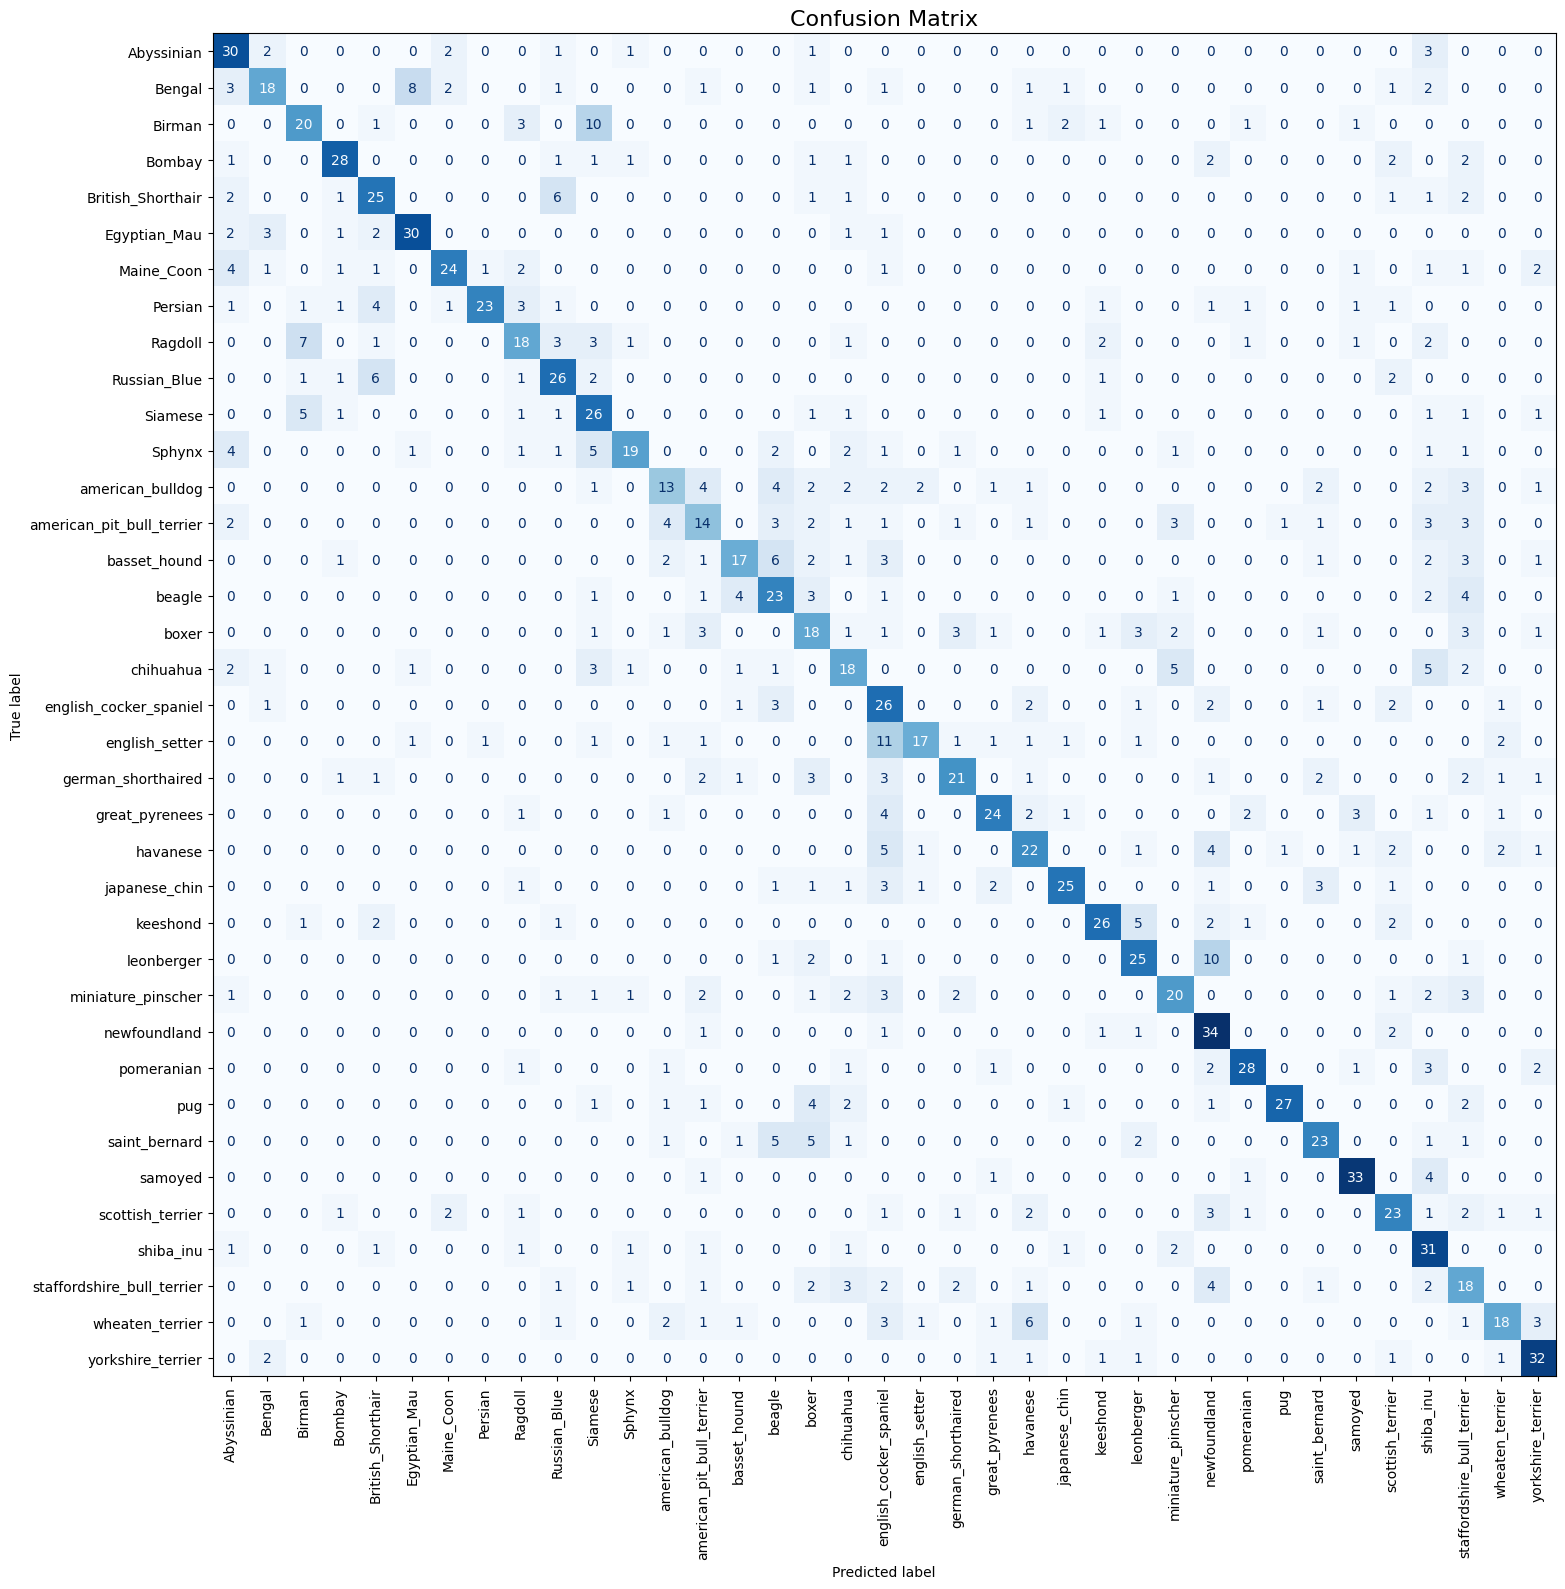


Generating ROC-AUC Curve...


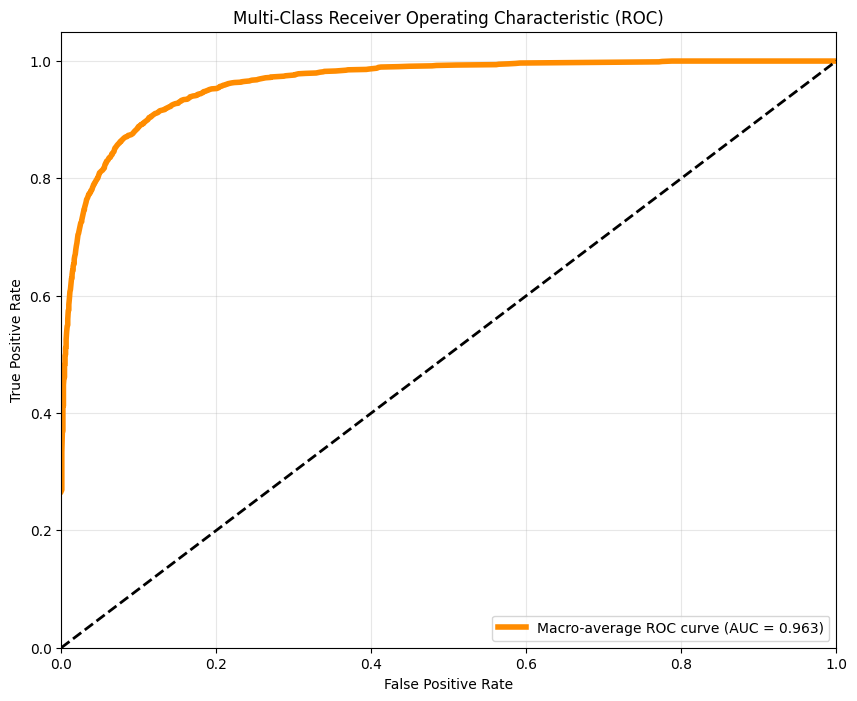


Visualizing Sample Predictions...


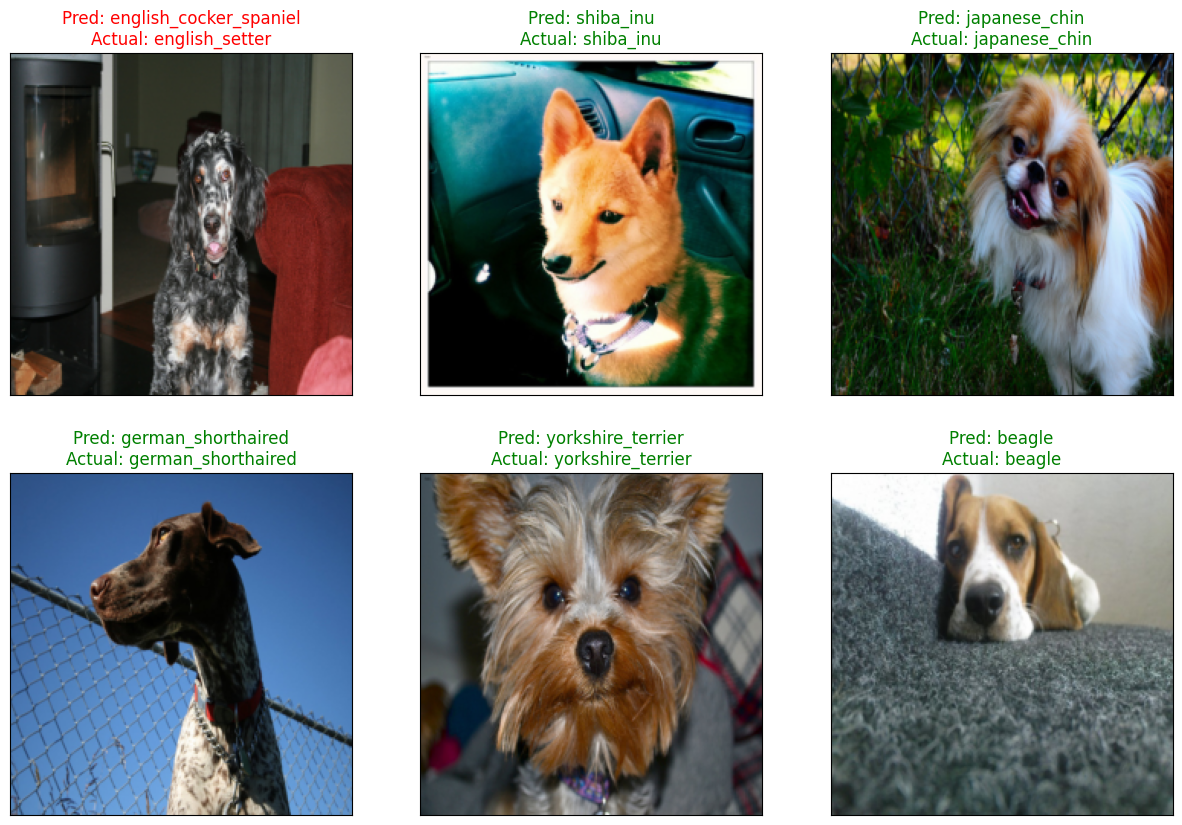

In [6]:
evaluator = ModelEvaluator(loaded_model, test_loader, classes, device)


evaluator.generate_full_report()